# LAB | Imbalanced

**Load the data**

In this challenge, we will be working with Credit Card Fraud dataset.

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv

Metadata

- **distance_from_home:** the distance from home where the transaction happened.
- **distance_from_last_transaction:** the distance from last transaction happened.
- **ratio_to_median_purchase_price:** Ratio of purchased price transaction to median purchase price.
- **repeat_retailer:** Is the transaction happened from same retailer.
- **used_chip:** Is the transaction through chip (credit card).
- **used_pin_number:** Is the transaction happened by using PIN number.
- **online_order:** Is the transaction an online order.
- **fraud:** Is the transaction fraudulent. **0=legit** -  **1=fraud**


In [1]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
fraud = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv")
fraud.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**Steps:**

- **1.** What is the distribution of our target variable? Can we say we're dealing with an imbalanced dataset?
- **2.** Train a LogisticRegression.
- **3.** Evaluate your model. Take in consideration class importance, and evaluate it by selection the correct metric.
- **4.** Run **Oversample** in order to balance our target variable and repeat the steps above, now with balanced data. Does it improve the performance of our model? 
- **5.** Now, run **Undersample** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model?
- **6.** Finally, run **SMOTE** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model? 

In [3]:
# Target distribution
fraud['fraud'].value_counts()
fraud['fraud'].value_counts(normalize=True)

fraud
0.0    0.912597
1.0    0.087403
Name: proportion, dtype: float64

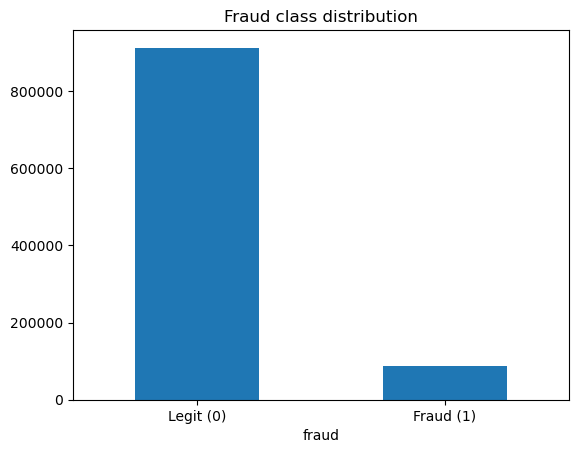

In [4]:
# plotting the target distribution
import matplotlib.pyplot as plt

fraud['fraud'].value_counts().plot(kind='bar')
plt.title('Fraud class distribution')
plt.xticks([0,1], ['Legit (0)', 'Fraud (1)'], rotation=0)
plt.show()

The target variable fraud is highly imbalanced, with legitimate transactions (class 0) largely outnumbering fraudulent transactions (class 1). This means the dataset contains far more normal transactions than fraud cases.
Because of this imbalance, accuracy alone is not a reliable metric to evaluate the model. A model could achieve high accuracy simply by predicting most transactions as legitimate. Therefore, metrics such as recall, precision, F1-score, and ROC-AUC are more appropriate to assess how well the model detects fraudulent transactions.

# Logistic Regression

In [5]:
# split the data into train and test sets
X = fraud.drop('fraud', axis=1)
y = fraud['fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# train baseline model
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

# Evaluate the model

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[181291   1228]
 [  6916  10565]]
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98    182519
         1.0       0.90      0.60      0.72     17481

    accuracy                           0.96    200000
   macro avg       0.93      0.80      0.85    200000
weighted avg       0.96      0.96      0.96    200000

ROC-AUC: 0.9670424835344712


The baseline Logistic Regression model achieves a high accuracy of 96%, which initially suggests strong performance. However, due to the class imbalance, accuracy alone can be misleading.
When looking at the minority class (fraud), the model achieves recall of 0.60, meaning it only identifies about 60% of fraudulent transactions. This indicates that a significant number of fraud cases are still missed.
The model also shows high precision (0.90), meaning that when it predicts fraud, it is usually correct.
Overall, the baseline model performs reasonably well but struggles to capture all fraud cases due to the imbalance in the dataset.

# Oversampling

In [8]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_over.value_counts())

fraud
0.0    730078
1.0     69922
Name: count, dtype: int64
fraud
0.0    730078
1.0    730078
Name: count, dtype: int64


In [9]:
log_reg_over = LogisticRegression(max_iter=1000)
log_reg_over.fit(X_train_over, y_train_over)

y_pred_over = log_reg_over.predict(X_test)
y_prob_over = log_reg_over.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_over))
print(classification_report(y_test, y_pred_over))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_over))

[[170392  12127]
 [   910  16571]]
              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96    182519
         1.0       0.58      0.95      0.72     17481

    accuracy                           0.93    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.93      0.94    200000

ROC-AUC: 0.9795270159857119


After applying Random Oversampling, the training dataset becomes balanced by duplicating minority class examples.
This significantly improves the model’s ability to detect fraud, increasing recall from 0.60 to 0.95, meaning the model now identifies most fraudulent transactions.
However, precision drops to 0.58, indicating that the model generates more false positives by labeling legitimate transactions as fraud.
Although overall accuracy decreases slightly, the model becomes much more effective at detecting fraud, which is often the main objective in fraud detection problems.

# Undersampling

In [10]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_under.value_counts())

fraud
0.0    730078
1.0     69922
Name: count, dtype: int64
fraud
0.0    69922
1.0    69922
Name: count, dtype: int64


In [11]:
log_reg_under = LogisticRegression(max_iter=1000)
log_reg_under.fit(X_train_under, y_train_under)

y_pred_under = log_reg_under.predict(X_test)
y_prob_under = log_reg_under.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_under))
print(classification_report(y_test, y_pred_under))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_under))

[[170384  12135]
 [   917  16564]]
              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96    182519
         1.0       0.58      0.95      0.72     17481

    accuracy                           0.93    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.93      0.94    200000

ROC-AUC: 0.9795768729938433


With Random Undersampling, the majority class is reduced to match the number of fraud cases, balancing the dataset by removing legitimate transactions.
This method produces results very similar to oversampling, with recall increasing to about 0.95, allowing the model to detect most fraud cases.
However, like oversampling, precision decreases to around 0.58, meaning more legitimate transactions are incorrectly flagged as fraud.
While undersampling improves fraud detection, it may discard useful information from the majority class, which can sometimes limit model performance.

# SMOTE

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

fraud
0.0    730078
1.0     69922
Name: count, dtype: int64
fraud
0.0    730078
1.0    730078
Name: count, dtype: int64


In [13]:
log_reg_smote = LogisticRegression(max_iter=1000)
log_reg_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = log_reg_smote.predict(X_test)
y_prob_smote = log_reg_smote.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

[[170496  12023]
 [   942  16539]]
              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96    182519
         1.0       0.58      0.95      0.72     17481

    accuracy                           0.94    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.94      0.94    200000

ROC-AUC: 0.9791803923331776


SMOTE generates synthetic minority class samples instead of simply duplicating existing ones. This helps create a more diverse representation of fraud cases in the training data.
Similar to oversampling and undersampling, SMOTE greatly improves fraud detection, increasing recall to approximately 0.95.
However, precision remains relatively low (0.58), meaning the model still produces more false positives.
Overall, SMOTE provides balanced performance and maintains strong ROC-AUC while improving the detection of fraudulent transactions.

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = pd.DataFrame({
    'Model': ['Baseline', 'Oversampling', 'Undersampling', 'SMOTE'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_over),
        accuracy_score(y_test, y_pred_under),
        accuracy_score(y_test, y_pred_smote)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_over),
        precision_score(y_test, y_pred_under),
        precision_score(y_test, y_pred_smote)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_over),
        recall_score(y_test, y_pred_under),
        recall_score(y_test, y_pred_smote)
    ],
    'F1': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_over),
        f1_score(y_test, y_pred_under),
        f1_score(y_test, y_pred_smote)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_over),
        roc_auc_score(y_test, y_prob_under),
        roc_auc_score(y_test, y_prob_smote)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.959280,0.895870,0.604370,0.721801,0.967042
1,Oversampling,0.934815,0.577427,0.947943,0.717686,0.979527
2,Undersampling,0.934740,0.577163,0.947543,0.717367,0.979577
3,SMOTE,0.935175,0.579056,0.946113,0.718415,0.979180


# Final conclusion
The dataset is highly imbalanced, with legitimate transactions significantly outnumbering fraudulent ones. Because of this, accuracy alone is not a reliable metric for evaluating model performance. Instead, recall, precision, F1-score, and ROC-AUC provide a better understanding of how well the model detects fraud.

The baseline Logistic Regression model achieved the highest accuracy and precision but struggled to detect fraudulent transactions, with a recall of only 0.60. This indicates that many fraud cases were missed.

After applying resampling techniques (Oversampling, Undersampling, and SMOTE), recall improved significantly to around 0.95, meaning the models were able to detect most fraudulent transactions. However, this improvement came at the cost of lower precision, resulting in more false positives.

Overall, all balancing techniques substantially improved fraud detection. Among them, undersampling achieved the highest ROC-AUC, while oversampling and SMOTE produced very similar performance. These results show that balancing the dataset helps the model better identify minority class events such as fraud.